In [2]:
# Make this notebook work from either fine-tuning/ or fine-tuning/pre-demo/
# (idempotent: re-running is safe)
import os
from pathlib import Path
_here = Path.cwd()
if _here.name in ('pre-demo', 'live-demo'):
    os.chdir(_here.parent)
print('cwd:', Path.cwd())


cwd: c:\Users\okofoworola\Acme Health Demo\fine-tuning


# Lab 02 · Direct Preference Optimization — teach it tone

A frightened member who just got a cancer diagnosis needs more than a correct answer — a factually-right reply can still land cold, and tone is exactly what members remember. DPO teaches bedside manner from preference pairs: load warm-vs-cold answers (`preferred_output` vs `non_preferred_output`), run a DPO job on `gpt-4o-mini`, and compare base vs DPO on an emotional prompt. The DPO model leads with empathy, then names concrete Acme next steps. *We didn't add facts — we taught it how Acme wants members to feel.*

---
## Step 1 — Config & client

In [3]:
import os, json, time, requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

load_dotenv()

AZURE_OPENAI_ENDPOINT    = os.environ['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_VERSION = os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview')
BASE_MODEL               = os.environ.get('BASE_MODEL', 'gpt-4o-mini-2024-07-18')
BASE_DEPLOYMENT          = os.environ.get('BASE_DEPLOYMENT', 'gpt-4o-mini')
SUBSCRIPTION_ID          = os.environ['AZURE_SUBSCRIPTION_ID']
RESOURCE_GROUP           = os.environ['AZURE_RESOURCE_GROUP']
RESOURCE_NAME            = os.environ['AZURE_RESOURCE_NAME']
TENANT_ID                = os.environ.get('AZURE_TENANT_ID')

SYSTEM_PROMPT = (
    'You are the Acme Health Member Services assistant. Be warm, empathetic, '
    'and proactive. Always validate the member\'s feelings before solving the '
    'problem, offer multiple concrete next steps, and stay calm.'
)

_cred = DefaultAzureCredential(interactive_browser_tenant_id=TENANT_ID) if TENANT_ID else DefaultAzureCredential()

client = AzureOpenAI(
    azure_endpoint          = AZURE_OPENAI_ENDPOINT,
    azure_ad_token_provider = lambda: _cred.get_token('https://cognitiveservices.azure.com/.default').token,
    api_version             = AZURE_OPENAI_API_VERSION,
)

print(f'Endpoint: {AZURE_OPENAI_ENDPOINT}')
print(f'Base    : {BASE_MODEL}')

Endpoint: https://aif-shuttervoice-dev.cognitiveservices.azure.com/
Base    : gpt-4o-mini-2024-07-18


---
## Step 2 — Load preference pairs and convert to DPO JSONL

Azure OpenAI DPO format:
```json
{
  "input": { "messages": [{"role":"system",...},{"role":"user",...}] },
  "preferred_output":     [{"role":"assistant","content":"good reply"}],
  "non_preferred_output": [{"role":"assistant","content":"bad reply"}]
}
```

In [4]:
SRC      = Path('data/acme_dpo_training_data.json')
DPO_JSONL = Path('data/acme_dpo.jsonl')

pairs = json.loads(SRC.read_text(encoding='utf-8'))

def _normalize_input(raw_input):
    """Source format: list[{role, content}]. Ensure exactly one system msg
    (ours) followed by the user turn(s)."""
    if isinstance(raw_input, str):
        return [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': raw_input },
        ]
    msgs = [m for m in raw_input if m.get('role') != 'system']
    return [{ 'role': 'system', 'content': SYSTEM_PROMPT }, *msgs]

with open(DPO_JSONL, 'w', encoding='utf-8') as f:
    for p in pairs:
        rec = {
            'input': { 'messages': _normalize_input(p['input']) },
            'preferred_output':     [{ 'role': 'assistant', 'content': p['preferred_output'][0]['content'] if isinstance(p['preferred_output'], list) else p['preferred_output'] }],
            'non_preferred_output': [{ 'role': 'assistant', 'content': p['non_preferred_output'][0]['content'] if isinstance(p['non_preferred_output'], list) else p['non_preferred_output'] }],
        }
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

print(f'Wrote {len(pairs)} preference pairs to {DPO_JSONL}')
print('\nSample (first pair):')
with open(DPO_JSONL, 'r', encoding='utf-8') as f:
    print(json.dumps(json.loads(f.readline()), indent=2)[:900] + '...')

Wrote 12 preference pairs to data\acme_dpo.jsonl

Sample (first pair):
{
  "input": {
    "messages": [
      {
        "role": "system",
        "content": "You are the Acme Health Member Services assistant. Be warm, empathetic, and proactive. Always validate the member's feelings before solving the problem, offer multiple concrete next steps, and stay calm."
      },
      {
        "role": "user",
        "content": "My medication costs $480 a month \u2014 this is killing me financially. There has to be something cheaper."
      }
    ]
  },
  "preferred_output": [
    {
      "role": "assistant",
      "content": "I'm really sorry \u2014 that's a big monthly hit and I want to help you bring it down today. A few real options I can check right now: first, is there a generic or therapeutic alternative on Tier 1 ($10) that your provider could switch you to? Second, the Acme Mail-Order Pharmacy fills a 90-day supply at the 60-day copay \u2014 that alone ...


---
## Step 3 — BEFORE: base model on emotionally-loaded prompts

In [5]:
TEST_PROMPTS = [
    'I just got diagnosed with cancer and my whole family is terrified. I have no idea what to do next.',
    'My specialist appointment is three weeks out and my pain is getting worse. I feel like nobody at Acme cares.',
    'This is the third time I\'ve been billed wrong this year. I\'m exhausted and I\'m about to switch insurance.',
]

print('BEFORE DPO - Base Model')
print('=' * 75)

base_replies = []
for i, q in enumerate(TEST_PROMPTS, 1):
    r = client.chat.completions.create(
        model       = BASE_DEPLOYMENT,
        messages    = [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': q },
        ],
        temperature = 0.0,
        max_tokens  = 280,
    )
    a = r.choices[0].message.content.strip()
    base_replies.append(a)
    print(f'\nQ{i}: {q}')
    print(f'A{i}: {a}')

BEFORE DPO - Base Model

Q1: I just got diagnosed with cancer and my whole family is terrified. I have no idea what to do next.
A1: I’m truly sorry to hear about your diagnosis. It’s completely understandable that you and your family are feeling scared and overwhelmed right now. This is a lot to process, and it’s important to take things one step at a time.

Here are some concrete next steps you can consider:

1. **Connect with Your Care Team**: Reach out to your oncologist or healthcare provider to discuss your diagnosis in detail. They can provide you with information about your specific type of cancer, treatment options, and what to expect moving forward.

2. **Gather Support**: Don’t hesitate to lean on your family and friends for support. It can be helpful to talk about your feelings and fears with them. You might also consider joining a support group, either in-person or online, where you can connect with others who are going through similar experiences.

3. **Educate Yourself**:

---
## Step 4 — Upload preference JSONL and submit DPO job

**DPO hyperparameters:**
- `beta = 0.1` controls how aggressively the model moves toward preferred (lower = bigger style shift)
- `l2_multiplier = 0.1` keeps the model from drifting too far from the base

In [6]:
upload = client.files.create(file=open(DPO_JSONL, 'rb'), purpose='fine-tune')
training_file_id = upload.id
print(f'Uploaded: {training_file_id} ({upload.status})')

# Wait for the file to finish processing - DPO jobs reject `pending` files.
print('Waiting for file to be processed...')
for _ in range(60):
    f = client.files.retrieve(training_file_id)
    print(f'  status: {f.status}')
    if f.status == 'processed':
        break
    if f.status in ('error', 'deleted'):
        raise RuntimeError(f'File ended in status {f.status}')
    time.sleep(5)

job = client.fine_tuning.jobs.create(
    training_file = training_file_id,
    model         = BASE_MODEL,
    suffix        = 'acme-dpo',
    seed          = 42,
    method        = {
        'type': 'dpo',
        'dpo': {
            'hyperparameters': {
                'beta': 0.1,
                'l2_multiplier': 0.1,
                'n_epochs': 3,
            }
        }
    },
    extra_body = { 'trainingType': 'GlobalStandard' },
)
job_id = job.id
print(f'\nDPO Job  : {job_id}')
print(f'Status   : {job.status}')

Uploaded: file-37be19424adf4bdd812b02740ca5d8a7 (pending)
Waiting for file to be processed...
  status: processed

DPO Job  : ftjob-ecab63d27dff429b80bb8d9bd7801d85
Status   : pending


---
## Step 5 — Monitor

In [ ]:
# Step 5 - Monitor. Self-contained: works after kernel restart and
# short-circuits if the DPO job already succeeded.
import os, time
from dotenv import load_dotenv

print('--- Step 5 starting...', flush=True)

# Rebuild client if missing (kernel restart)
if 'client' not in globals():
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential, get_bearer_token_provider
    _cred = DefaultAzureCredential()
    _tp = get_bearer_token_provider(_cred, 'https://cognitiveservices.azure.com/.default')
    client = AzureOpenAI(
        azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
        api_version=os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
        azure_ad_token_provider=_tp,
    )
    print('  rebuilt client from .env', flush=True)

# Resolve job_id: globals -> .env (DPO_JOB_ID) -> most recent succeeded DPO job.
# Looking the job up from history keeps this resumable without a hardcoded id.
# The '-dpo' match is brand-agnostic: it resolves both a fresh '<brand>-dpo'
# run and any pre-existing DPO model in the resource.
job_id = globals().get('job_id') or os.environ.get('DPO_JOB_ID') \
    or next((jb.id for jb in client.fine_tuning.jobs.list()
             if '-dpo' in (jb.fine_tuned_model or '') and jb.status == 'succeeded'), None)
if not job_id:
    raise RuntimeError('No DPO job found - run Step 4 first or set DPO_JOB_ID.')
print(f'  job_id: {job_id}', flush=True)

# Single status check first - if already terminal, skip the poll loop
job_status = client.fine_tuning.jobs.retrieve(job_id)
print(f'  current status: {job_status.status}', flush=True)

# Bounded poll: wait up to MAX_WAIT_MIN, then hand control back so the
# kernel never appears frozen. Re-run this cell to keep waiting - the
# short-circuit above resumes instantly once the job is terminal.
MAX_WAIT_MIN = 20
POLL_EVERY_S = 30
if job_status.status in ('succeeded', 'failed', 'cancelled'):
    print('  -> terminal state, skipping poll loop', flush=True)
else:
    print(f'  polling every {POLL_EVERY_S}s for up to {MAX_WAIT_MIN} min '
          '(stop button interrupts; re-run to keep waiting)...', flush=True)
    t0 = time.time()
    deadline = t0 + MAX_WAIT_MIN * 60
    while time.time() < deadline:
        time.sleep(POLL_EVERY_S)
        job_status = client.fine_tuning.jobs.retrieve(job_id)
        elapsed = int(time.time() - t0)
        print(f'  [+{elapsed:>4}s] {job_status.status}', flush=True)
        if job_status.status in ('succeeded', 'failed', 'cancelled'):
            break

if job_status.status == 'succeeded':
    fine_tuned_model = job_status.fine_tuned_model
    print(f'\nDPO model: {fine_tuned_model}', flush=True)
elif job_status.status in ('failed', 'cancelled'):
    print(f'\nJob ended: {job_status.status}', flush=True)
    print(getattr(job_status, 'error', None), flush=True)
else:
    print(f'\nStill {job_status.status} after {MAX_WAIT_MIN} min. '
          'DPO training typically takes 20-40 min - re-run this cell to keep '
          'monitoring (the kernel is free to use in the meantime).', flush=True)

print('--- Step 5 done. ---', flush=True)


--- Step 5 starting...
  job_id: ftjob-ecab63d27dff429b80bb8d9bd7801d85
  current status: pending
  polling every 30s for up to 20 min (stop button interrupts; re-run to keep waiting)...
  [+  32s] pending
  [+  65s] pending
  [+  98s] pending
  [+ 131s] pending
  [+ 164s] pending
  [+ 197s] pending
  [+ 231s] pending
  [+ 264s] pending
  [+ 297s] running
  [+ 330s] running
  [+ 364s] running
  [+ 397s] running
  [+ 430s] running
  [+ 463s] running
  [+ 496s] running
  [+ 529s] running
  [+ 562s] running
  [+ 596s] running
  [+ 629s] running


---
## Step 6 — DPO loss curve

Lower `train_loss` = model is learning to prefer the good replies.

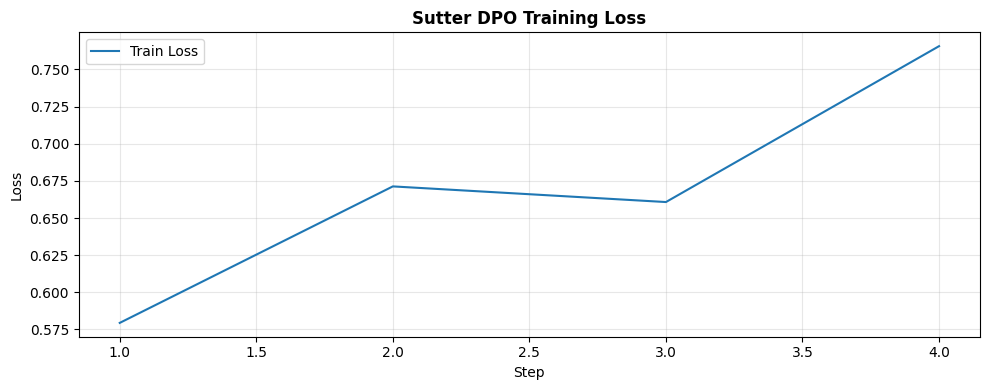

In [5]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Work from fine-tuning/ so the relative data/ path resolves (idempotent)
_here = Path.cwd()
if _here.name in ('pre-demo', 'live-demo'):
    os.chdir(_here.parent)

# Rebuild client if missing (kernel restart)
if 'client' not in globals():
    from dotenv import load_dotenv
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential, get_bearer_token_provider
    _cred = DefaultAzureCredential()
    _tp = get_bearer_token_provider(_cred, 'https://cognitiveservices.azure.com/.default')
    client = AzureOpenAI(
        azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
        api_version=os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
        azure_ad_token_provider=_tp,
    )

# Resolve job_id: globals -> .env (DPO_JOB_ID) -> known successful job
job_id = globals().get('job_id') or os.environ.get('DPO_JOB_ID') \
    or 'ftjob-ecab63d27dff429b80bb8d9bd7801d85'

final_job = client.fine_tuning.jobs.retrieve(job_id)
if final_job.result_files:
    content = client.files.content(final_job.result_files[0]).read()
    Path('data/acme_dpo_results.csv').write_bytes(content)
    df = pd.read_csv('data/acme_dpo_results.csv')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_title('Acme DPO Training Loss', fontweight='bold')
    if 'train_loss' in df.columns:
        ax.plot(df['step'], df['train_loss'], label='Train Loss', linewidth=1.5)
    if 'full_valid_loss' in df.columns:
        m = df['full_valid_loss'].notna()
        ax.scatter(df.loc[m, 'step'], df.loc[m, 'full_valid_loss'], label='Full Valid Loss', color='red', zorder=5)
    ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig('data/acme_dpo_metrics.png', dpi=150); plt.show()
else:
    print('No result file yet.')

---
## Step 7 — Deploy

In [1]:
import os, json, time, requests

# Rebuild creds/client/config if missing (kernel restart)
if '_cred' not in globals() or 'client' not in globals():
    from dotenv import load_dotenv
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential
    _cred = DefaultAzureCredential()
    client = AzureOpenAI(
        azure_endpoint          = os.environ['AZURE_OPENAI_ENDPOINT'],
        azure_ad_token_provider = lambda: _cred.get_token('https://cognitiveservices.azure.com/.default').token,
        api_version             = os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
    )

SUBSCRIPTION_ID = globals().get('SUBSCRIPTION_ID') or os.environ['AZURE_SUBSCRIPTION_ID']
RESOURCE_GROUP  = globals().get('RESOURCE_GROUP')  or os.environ['AZURE_RESOURCE_GROUP']
RESOURCE_NAME   = globals().get('RESOURCE_NAME')   or os.environ['AZURE_RESOURCE_NAME']

DPO_DEPLOYMENT_NAME = 'acme-dpo-deployment'

# Resolve the model name. The DPO job is authoritative (it can never go stale);
# fall back to globals -> env only if the job lookup is unavailable.
job_id = globals().get('job_id') or os.environ.get('DPO_JOB_ID') \
    or 'ftjob-ecab63d27dff429b80bb8d9bd7801d85'
fine_tuned_model = None
try:
    _job = client.fine_tuning.jobs.retrieve(job_id)
    fine_tuned_model = _job.fine_tuned_model
    print(f'Job {job_id} -> status={_job.status}, model={fine_tuned_model}')
except Exception as e:
    print(f'Could not retrieve job {job_id}: {e}')
fine_tuned_model = fine_tuned_model or globals().get('fine_tuned_model') or os.environ.get('DPO_MODEL')
if not fine_tuned_model:
    raise RuntimeError('No fine_tuned_model resolved - run Step 5 or set DPO_MODEL/DPO_JOB_ID.')
print(f'Deploying: {fine_tuned_model}')

auth = _cred.get_token('https://management.azure.com/.default').token
deploy_url = (
    f'https://management.azure.com/subscriptions/{SUBSCRIPTION_ID}'
    f'/resourceGroups/{RESOURCE_GROUP}'
    f'/providers/Microsoft.CognitiveServices/accounts/{RESOURCE_NAME}'
    f'/deployments/{DPO_DEPLOYMENT_NAME}'
)

# Developer SKU is free/ephemeral but isn't available on every resource/region.
# Fall back to GlobalStandard (what the SFT deploy uses) if it's rejected.
deployed = False
for sku in ('Developer', 'GlobalStandard'):
    r = requests.put(
        deploy_url,
        params  = { 'api-version': '2024-10-01' },
        headers = { 'Authorization': f'Bearer {auth}', 'Content-Type': 'application/json' },
        json    = {
            'sku': { 'name': sku, 'capacity': 1 },
            'properties': { 'model': { 'format': 'OpenAI', 'name': fine_tuned_model, 'version': '1' } },
        },
    )
    print(f'SKU {sku}: HTTP {r.status_code} {r.reason}')
    if r.status_code in (200, 201):
        deployed = True
        print(f'Accepted with SKU: {sku}')
        break
    body = r.json()
    print(json.dumps(body, indent=2))
    # Only try the next SKU when the SKU itself was rejected; bail on other errors.
    if 'sku' not in json.dumps(body).lower():
        break

if not deployed:
    raise RuntimeError('Deployment request was not accepted - see error above.')

# Bounded provisioning poll (only runs after an accepted PUT) so it never hangs.
status_url = deploy_url + '?api-version=2024-10-01'
DEPLOY_WAIT_MIN = 10
_deadline = time.time() + DEPLOY_WAIT_MIN * 60
while time.time() < _deadline:
    s = requests.get(status_url, headers={ 'Authorization': f'Bearer {auth}' })
    state = s.json().get('properties', {}).get('provisioningState', 'Unknown')
    print(f'[{time.strftime("%H:%M:%S")}] {state}')
    if state == 'Succeeded': break
    if state in ('Failed', 'Canceled'): print(json.dumps(s.json(), indent=2)); break
    time.sleep(20)
else:
    print(f'Still provisioning after {DEPLOY_WAIT_MIN} min - re-run this cell to keep checking.')

Job ftjob-ecab63d27dff429b80bb8d9bd7801d85 -> status=succeeded, model=gpt-4o-mini-2024-07-18.ft-ecab63d27dff429b80bb8d9bd7801d85-acme-dpo
Deploying: gpt-4o-mini-2024-07-18.ft-ecab63d27dff429b80bb8d9bd7801d85-acme-dpo
SKU Developer: HTTP 400 Bad Request
{
  "error": {
    "code": "InvalidResourceProperties",
    "message": "The deployment sku name 'Developer' is invalid."
  }
}
SKU GlobalStandard: HTTP 201 Created
Accepted with SKU: GlobalStandard
[17:11:13] Creating
[17:11:34] Creating
[17:11:55] Creating
[17:12:17] Creating
[17:12:38] Creating
[17:12:59] Creating
[17:13:20] Creating
[17:13:41] Succeeded


---
## Step 8 — AFTER: DPO model on the same prompts

In [2]:
# Step 8 - AFTER eval. Self-contained: rebuilds any missing state
# (client, prompts, deployment name) so this cell works after a
# kernel restart without re-running every prior cell.
import os, json, sys, time
from pathlib import Path
from dotenv import load_dotenv

print('--- Step 8 starting...', flush=True)

if 'client' not in globals():
    print('  rebuilding client from .env', flush=True)
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential
    _cred = DefaultAzureCredential()
    client = AzureOpenAI(
        azure_endpoint          = os.environ['AZURE_OPENAI_ENDPOINT'],
        azure_ad_token_provider = lambda: _cred.get_token('https://cognitiveservices.azure.com/.default').token,
        api_version             = os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
    )

SYSTEM_PROMPT = globals().get('SYSTEM_PROMPT', (
    'You are the Acme Health Member Services assistant. Be warm, empathetic, '
    'and proactive. Always validate the member\'s feelings before solving the '
    'problem, offer multiple concrete next steps, and stay calm.'))

TEST_PROMPTS = globals().get('TEST_PROMPTS', [
    'I just got diagnosed with cancer and my whole family is terrified. I have no idea what to do next.',
    'My specialist appointment is three weeks out and my pain is getting worse. I feel like nobody at Acme cares.',
    "This is the third time I've been billed wrong this year. I'm exhausted and I'm about to switch insurance.",
])

DPO_DEPLOYMENT_NAME = globals().get('DPO_DEPLOYMENT_NAME', 'acme-dpo-deployment')

print(f'  deployment: {DPO_DEPLOYMENT_NAME}', flush=True)
print(f'  prompts:    {len(TEST_PROMPTS)}', flush=True)
print('AFTER DPO - Fine-Tuned Model', flush=True)
print('=' * 75, flush=True)

dpo_replies = []
for i, q in enumerate(TEST_PROMPTS, 1):
    t = time.time()
    print(f'\n[{i}/{len(TEST_PROMPTS)}] asking DPO model... ({q[:60]}...)', flush=True)
    r = client.chat.completions.create(
        model       = DPO_DEPLOYMENT_NAME,
        messages    = [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': q },
        ],
        temperature = 0.0,
        max_tokens  = 280,
    )
    a = r.choices[0].message.content.strip()
    dpo_replies.append(a)
    print(f'  ({time.time()-t:.1f}s)', flush=True)
    print(f'Q{i}: {q}', flush=True)
    print(f'A{i}: {a}', flush=True)

# Cache so Step 9 always has fresh results to compare against.
# Preserve any prior 'base' already on disk so re-running Step 8
# doesn't wipe out Step 3's BEFORE replies.
_existing = {}
if Path('dpo_eval_results.json').exists():
    try:
        _existing = json.loads(Path('dpo_eval_results.json').read_text(encoding='utf-8'))
    except Exception:
        pass
_base_to_cache = globals().get('base_replies') or _existing.get('base', [])
Path('dpo_eval_results.json').write_text(json.dumps({
    'prompts': TEST_PROMPTS,
    'base': _base_to_cache,
    'dpo': dpo_replies,
}, indent=2), encoding='utf-8')

print('\n--- Step 8 done. ---', flush=True)


--- Step 8 starting...
  deployment: acme-dpo-deployment
  prompts:    3
AFTER DPO - Fine-Tuned Model

[1/3] asking DPO model... (I just got diagnosed with cancer and my whole family is terr...)
  (13.2s)
Q1: I just got diagnosed with cancer and my whole family is terrified. I have no idea what to do next.
A1: I’m so sorry to hear about your diagnosis. It’s completely understandable to feel overwhelmed and scared right now, both for you and your family. This is a lot to process, and it’s important to take things one step at a time.

Here are some next steps you might consider:

1. **Connect with Your Care Team**: Reach out to your oncologist or healthcare provider to discuss your diagnosis in detail. They can provide you with information about your specific type of cancer, treatment options, and what to expect moving forward.

2. **Gather Support**: Talk to your family about how you’re feeling and encourage them to share their feelings too. You might also consider joining a support gro

---
## Step 9 — Side-by-side

In [3]:
# Step 9 - Side-by-side. Self-contained: falls back to the cached
# results from Step 8 if base_replies / dpo_replies aren't in memory.
import json
from pathlib import Path

print('--- Step 9 starting...', flush=True)

_cache_path = Path('dpo_eval_results.json')
_need_cache = (
    'base_replies' not in globals() or not globals().get('base_replies')
    or 'dpo_replies' not in globals() or not globals().get('dpo_replies')
)
if _need_cache and _cache_path.exists():
    print('  loading from cache:', _cache_path.resolve(), flush=True)
    _cache = json.loads(_cache_path.read_text(encoding='utf-8'))
    TEST_PROMPTS = _cache.get('prompts', globals().get('TEST_PROMPTS', []))
    base_replies = _cache.get('base', globals().get('base_replies', []))
    dpo_replies  = _cache.get('dpo',  globals().get('dpo_replies',  []))

print('Side-by-Side: Base vs DPO', flush=True)
print('=' * 75, flush=True)
for i, q in enumerate(TEST_PROMPTS):
    print(f'\nQ{i+1}: {q}', flush=True)
    b = base_replies[i] if i < len(base_replies) else '(missing - run Step 3)'
    d = dpo_replies[i]  if i < len(dpo_replies)  else '(missing - run Step 8)'
    print(f'\n  Base : {b}', flush=True)
    print(f'\n  DPO  : {d}', flush=True)
    print('-' * 75, flush=True)

print('\nWhat to highlight in the demo:', flush=True)
print(' - DPO opens with empathy ("I hear you", "that sounds...")', flush=True)
print(' - DPO offers 2-3 concrete next steps, not one boilerplate line', flush=True)
print(' - DPO never tells the member to "just call back later"', flush=True)
print('\n--- Step 9 done. ---', flush=True)


--- Step 9 starting...
  loading from cache: C:\Users\okofoworola\Acme Health Demo\fine-tuning\pre-demo\dpo_eval_results.json
Side-by-Side: Base vs DPO

Q1: I just got diagnosed with cancer and my whole family is terrified. I have no idea what to do next.

  Base : (missing - run Step 3)

  DPO  : I’m so sorry to hear about your diagnosis. It’s completely understandable to feel overwhelmed and scared right now, both for you and your family. This is a lot to process, and it’s important to take things one step at a time.

Here are some next steps you might consider:

1. **Connect with Your Care Team**: Reach out to your oncologist or healthcare provider to discuss your diagnosis in detail. They can provide you with information about your specific type of cancer, treatment options, and what to expect moving forward.

2. **Gather Support**: Talk to your family about how you’re feeling and encourage them to share their feelings too. You might also consider joining a support group, either in

---
## Step 10 — Cleanup

In [ ]:
try:
    client.files.delete(training_file_id); print(f'Deleted file: {training_file_id}')
except Exception as e:
    print(f'Could not delete file: {e}')

auth = _cred.get_token('https://management.azure.com/.default').token
r = requests.delete(deploy_url, params={ 'api-version': '2024-10-01' },
                    headers={ 'Authorization': f'Bearer {auth}' })
print(f'Deployment delete: HTTP {r.status_code}')

print(f'\nDPO model name: {fine_tuned_model}')